In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# 讀取數據
course_data = pd.read_csv("enhanced_math_course_data.csv")

# 移除特定課名的列
excluded_courses = ["體育（一）","體育（二）", "服務學習（一）", "服務學習（二）"]
course_data = course_data[~course_data['科目名稱(連結課程地圖)             備註 \n             限選條件'].isin(excluded_courses)]

In [3]:
course_data = course_data.drop(['系所名稱', '學分', '時間', '教室'], axis=1)
# 僅對布林值和特定欄位進行替換
course_data['必選修'] = course_data['必選修'].replace({'必修': 0, '選修': 1, '必選': 2})
course_data = course_data.replace({True: 1, False: 0})
# 修正欄位名稱，去除空格和特殊字符
course_data.columns = course_data.columns.str.strip()
# 分離 "已選課人數" 和 "餘額"
course_data[['已選課人數', '餘額']] = course_data['已選課人數/餘額'].str.split('/', expand=True)
# 移除 '餘額' 列中值為 "網路選課不開放" 的行
course_data = course_data[course_data['餘額'] != '網路選課不開放']
# 處理 "餘額" 中的特殊值
course_data['餘額'] = course_data['餘額'].replace(['額滿'], 0)
# 將 "餘額" 列轉換為整數，非數字的值替換為 NaN 並填充為 0
course_data['餘額'] = pd.to_numeric(course_data['餘額'], errors='coerce').fillna(0).astype(int)
# 將 "已選課人數" 轉換為整數
course_data['已選課人數'] = pd.to_numeric(course_data['已選課人數'], errors='coerce').fillna(0).astype(int)
# 確保 '餘額' 列的類型為整數
course_data['餘額'] = pd.to_numeric(course_data['餘額'], errors='coerce').fillna(0).astype(int)
print(course_data.columns)

Index(['學年期', '科目名稱(連結課程地圖)             備註 \n             限選條件', '教師姓名*:主負責老師',
       '已選課人數/餘額', '系所名稱_label', '必選修', '類別_實習', '類別_講義', '數學_微積分', '數學_ODE',
       '數學_PDE', '數學_代數', '數學_幾何', '數學_數值分析', '數學_分析', '統計_數據分析', '統計_機率',
       '統計_時間數列', '統計_貝氏統計', '電腦科學_深度學習', '電腦科學_演算法', '電腦科學_資料結構', '電腦科學_人工智慧',
       '電腦科學_程式設計', '電機工程_電路設計', '電機工程_電磁學', '電機工程_模擬系統', '測量_測量技術', '測量_地圖繪製',
       '測量_GPS定位', '土木_結構設計', '土木_工程施工', '數學_應用線性代數', '數學_應用幾何', '電腦科學_機器學習',
       '電腦科學_系統設計', '電腦科學_網路技術', '電機工程_信號處理', '法律', '測量_大地測量', '測量_遙感探測',
       '測量_空間資訊', '測量_攝影測量', '統計_迴歸分析', '統計_抽樣方法', '統計_多變量分析', '統計_類別資料分析',
       '統計_工業應用', '統計_統計推論', '跨領域', '已選課人數', '餘額'],
      dtype='object')


C:\Users\78963\AppData\Local\Temp\ipykernel_20380\2394292096.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  course_data['必選修'] = course_data['必選修'].replace({'必修': 0, '選修': 1, '必選': 2})
C:\Users\78963\AppData\Local\Temp\ipykernel_20380\2394292096.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  course_data = course_data.replace({True: 1, False: 0})


In [4]:
course_data

,學年期,科目名稱(連結課程地圖) 備註 \n 限選條件,教師姓名*:主負責老師,已選課人數/餘額,系所名稱_label,必選修,類別_實習,類別_講義,數學_微積分,數學_ODE,...,測量_攝影測量,統計_迴歸分析,統計_抽樣方法,統計_多變量分析,統計_類別資料分析,統計_工業應用,統計_統計推論,跨領域,已選課人數,餘額
0,0108-2,微積分（二）,林育竹,54/16,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,54,16
1,0108-2,線性代數（二）,劉珈銘,67/13,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,67,13
2,0108-2,普通物理學（二）,游輝樟,54/16,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,54,16
3,0108-2,計算機概論與程式語言,沈士育,57/13,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,57,13
4,0108-2,高等微積分（二）,劉育佑,42/8,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,42,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0113-1,空間資訊整合與應用,朱宏杰,25/3,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,25,3
884,0113-1,水土保持工程,倪勝火,93/5,1,1,0,1,0,0,...,0,0,0,0,0,0,0,1,93,5
885,0113-1,工程實務－世曦論壇,廖學瑞,132/68,1,1,0,1,0,0,...,0,0,0,0,0,0,0,1,132,68
886,0113-1,合成孔徑雷達基礎原理與應用,蔡展榮,9/41,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,9,41


Mean Squared Error: 324.5084839786421
R^2 Score: 0.27554750540793316


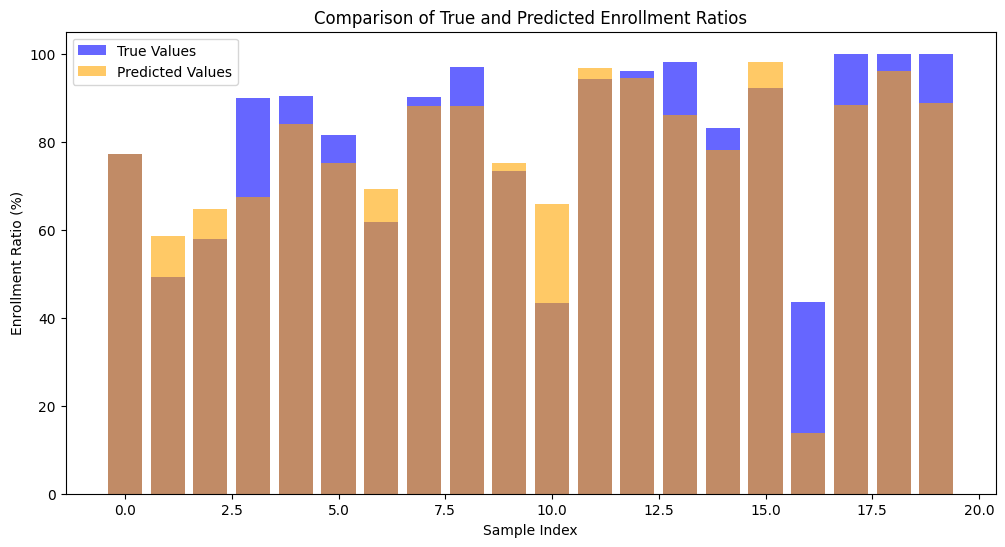

In [5]:
# 確保 "已選課人數" 列中沒有零，避免零除錯誤
course_data['已選課人數'] = course_data['已選課人數'].replace(0, 1)

# 新增 "餘額/已選課人數" 特徵
course_data['餘額_已選課人數比'] = course_data['已選課人數'] / (course_data['已選課人數'] + course_data['餘額']) * 100

# 特徵選擇（去除無關欄位）
X = course_data.drop(['學年期','已選課人數/餘額','已選課人數','餘額','餘額_已選課人數比','類別_講義','科目名稱(連結課程地圖)             備註 \n             限選條件', '教師姓名*:主負責老師'], axis=1)
y = course_data['餘額_已選課人數比']

# 分割訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 建立和訓練模型
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# 4. 預測和評估
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# 繪製長條圖來比較真實數據和預測數據
plt.figure(figsize=(12, 6))

# 取前20個樣本進行可視化
num_samples = 20
indices = range(num_samples)
plt.bar(indices, y_test.iloc[:num_samples], label='True Values', alpha=0.6, color='blue')
plt.bar(indices, y_pred[:num_samples], label='Predicted Values', alpha=0.6, color='orange')

plt.xlabel('Sample Index')
plt.ylabel('Enrollment Ratio (%)')
plt.title('Comparison of True and Predicted Enrollment Ratios')
plt.legend()
plt.show()


In [6]:
import joblib

# 保存模型到檔案
joblib.dump(rf_model, 'rf_model.pkl')
print("模型已保存到 'rf_model.pkl'")

模型已保存到 'rf_model.pkl'
